# Question 2: Parametric PODNN for Navier-Stokes

This notebook follows the same first stages as `Q1.ipynb`: build the FEM full order model, generate FOM snapshots, and construct POD spaces for velocity and pressure. The difference is the online stage: instead of solving the reduced Navier-Stokes equations with POD-Galerkin, we train a feed-forward neural network to predict the POD coefficients directly from the parameters $(\mu_0, \mu_1)$.


In [1]:
#Mount Colab to Google Drive to save and share files
from google.colab import drive
import os
drive.mount('/content/drive')
%cd /content/drive/MyDrive/MOR-project
!ls

!python3 -m pip install vtk
!python3 -m pip install pypolydim
import numpy as np
import argparse
import os.path
import scipy.sparse
import scipy.linalg
import vtk
import matplotlib.pyplot as plt
from pypolydim import polydim, gedim
from pypolydim.export_vtk_utilities import ExportVTKUtilities
from pypolydim.assembler_utilities import assembler_utilities
#import sys
#sys.path.insert(0, "/content/drive/MyDrive/MOR-project")
import other_utilities as other_ut



Mounted at /content/drive
/content/drive/MyDrive/MOR-project
Export	Meshes	other_utilities.py  __pycache__  Q1.ipynb
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 6.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 8.9 MB/s eta 0:00:0000:010:01m


In [2]:
#Initalize parameters
geometry_utilities_config = gedim.GeometryUtilitiesConfig()
geometry_utilities_config.tolerance1_d = 1.0e-6
geometry_utilities_config.tolerance2_d = 1.0e-12
geometry_utilities = gedim.GeometryUtilities(geometry_utilities_config)
mesh_utilities = gedim.MeshUtilities()
vtk_utilities = ExportVTKUtilities()

#All export folders path
# Export folder
export_file_path = "./Export/Test_1"
if not os.path.exists(export_file_path):
    os.makedirs(export_file_path)

# Mesh file path
export_mesh_path = export_file_path + "/Mesh"
if not os.path.exists(export_mesh_path):
    os.makedirs(export_mesh_path)

# Solution file path
export_solution_path = export_file_path + "/Solution"
if not os.path.exists(export_solution_path):
    os.makedirs(export_solution_path)

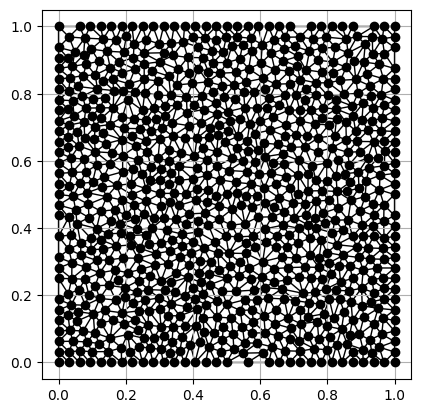

In [3]:
#Define the domain [0,1]x[0,1]
pde_domain = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D()
pde_domain.vertices = np.array([[0.0, 1.0, 1.0, 0.0],
                                [0.0, 0.0, 1.0, 1.0],
                                [0.0, 0.0, 0.0, 0.0]])
pde_domain.shape_type = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D.Domain_Shape_Types.parallelogram
pde_domain.area = 1.0

#Define the mesh
mesh_type = polydim.pde_tools.mesh.pde_mesh_utilities.MeshGenerator_Types_2D.triangular 
method_type = polydim.pde_tools.local_space_pcc_2_d.MethodTypes.fem_pcc     
method_order = 1
mesh_size = 0.001

mesh_data = gedim.MeshMatrices()
mesh = gedim.MeshMatricesDAO(mesh_data)

polydim.pde_tools.mesh.pde_mesh_utilities.create_mesh_2_d(geometry_utilities,
                                                          mesh_utilities,
                                                          mesh_type,
                                                          pde_domain,
                                                          mesh_size,
                                                          mesh)
mesh_geometric_data = polydim.pde_tools.mesh.pde_mesh_utilities.compute_mesh_2_d_geometry_data(geometry_utilities, mesh_utilities, mesh)

#plot the mesh
vtk_utilities.export_mesh(export_mesh_path, mesh)
other_ut.plot_mesh(mesh)

In [ ]:
print("Vertex markers:", np.unique(mesh_data.cell0_d_markers))
print("Edge markers:", np.unique(mesh_data.cell1_d_markers))

Vertex markers: [0 1 2 3 4 5 6 7 8]
Edge markers: [0 5 6 7 8]


In [ ]:
info_internal = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_internal.marker = 0

info_dirichlet = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.strong)
info_dirichlet.marker = 1

info_neumann_none = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_neumann_none.marker = 0

pressure_boundary_info = {
    0: info_internal,
    1: info_dirichlet, #fix pressure at (0,0) to 0
    2: info_neumann_none,
    3: info_neumann_none,
    4: info_neumann_none,
    5: info_neumann_none,
    6: info_neumann_none,
    7: info_neumann_none,
    8: info_neumann_none
}

speed_boundary_info = {
    0: info_internal,
    1: info_dirichlet,
    2: info_dirichlet,
    3: info_dirichlet,
    4: info_dirichlet,
    5: info_dirichlet,
    6: info_dirichlet,
    7: info_dirichlet,
    8: info_dirichlet
}

In [6]:
mesh_connectivity_data = polydim.pde_tools.mesh.MeshMatricesDAO_mesh_connectivity_data(mesh)

pressure_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 
                                                                                              1)
speed_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 
                                                                                             2)

dof_manager = polydim.pde_tools.do_fs.DOFsManager()

pressure_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(pressure_reference_element_data, 
                                                                                    mesh, 
                                                                                    pressure_boundary_info)
pressure_dofs_data = dof_manager.create_do_fs_2_d(pressure_mesh_dofs_info, 
                                                  mesh_connectivity_data)

speed_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(speed_reference_element_data, 
                                                                                 mesh, 
                                                                                 speed_boundary_info)
speed_dofs_data = dof_manager.create_do_fs_2_d(speed_mesh_dofs_info, 
                                               mesh_connectivity_data)

In [7]:
#amount of DOF's

pressure_n_dofs = pressure_dofs_data.number_do_fs
pressure_n_strongs = pressure_dofs_data.number_strongs
speed_n_dofs = speed_dofs_data.number_do_fs
speed_n_strongs = speed_dofs_data.number_strongs
tot_dofs = 2 * speed_n_dofs + pressure_n_dofs
tot_strongs = 2 * speed_n_strongs + pressure_n_strongs

print("P dofs\t", "P stgs\t", "U dofs\t", "U stgs\t", "T dofs\t", "T stgs")
print(pressure_n_dofs,"\t", pressure_n_strongs,"\t", speed_n_dofs,"\t", speed_n_strongs,"\t", tot_dofs,"\t", tot_strongs)

P dofs	 P stgs	 U dofs	 U stgs	 T dofs	 T stgs
829 	 1 	 2966 	 234 	 6761 	 469


In [ ]:
#assemble the FEM matrices
def pressure_strong_function(marker, x, y, z):
    return 0.0

def speed_x_strong_function(marker, x, y, z):
    return 0.0

def speed_y_strong_function(marker, x, y, z):
    return 0.0

p_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    pressure_mesh_dofs_info,
    pressure_dofs_data,
    pressure_reference_element_data,
    pressure_strong_function
)

u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    speed_mesh_dofs_info,
    speed_dofs_data,
    speed_reference_element_data,
    speed_x_strong_function
)

u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    speed_mesh_dofs_info,
    speed_dofs_data,
    speed_reference_element_data,
    speed_y_strong_function
)

strong_solution = np.concatenate([u_x_strong, u_y_strong, p_strong])

In [9]:
#check the dimensions 

print("strong_solution shape:", strong_solution.shape)

print("speed_n_dofs:", speed_n_dofs)
print("pressure_n_dofs:", pressure_n_dofs)
print("total expected:", 2 * speed_n_dofs + pressure_n_dofs)

strong_solution shape: (469,)
speed_n_dofs: 2966
pressure_n_dofs: 829
total expected: 6761


In [10]:
def one_term(x, y, z):  
    return 1.0

def b_x_term(x, y, z):  
    return np.array([\
        1.0,\
        0.0,\
        0.0])
def b_y_term(x, y, z):  
    return np.array([\
        0.0,\
        1.0,\
        0.0])


A_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    speed_dofs_data,
    speed_dofs_data,
    speed_reference_element_data,
    speed_reference_element_data,
    one_term
)

A_speed = other_ut.make_np_sparse(A_operator.operator_dofs)

J_A_x = other_ut.make_np_sparse(
    A_operator.operator_dofs,
    [tot_dofs, tot_dofs],
    [0, 0]
)

J_A_y = other_ut.make_np_sparse(
    A_operator.operator_dofs,
    [tot_dofs, tot_dofs],
    [speed_n_dofs, speed_n_dofs]
)

J_A_Base = J_A_x + J_A_y

B_x_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       pressure_dofs_data,
                                                                       speed_reference_element_data,
                                                                       pressure_reference_element_data,
                                                                       b_x_term)
B_y_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       pressure_dofs_data,
                                                                       speed_reference_element_data,
                                                                       pressure_reference_element_data,
                                                                       b_y_term)

J_B_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0])
J_B_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs])
J_BT_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0], True)
J_BT_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs], True)


J_B = -J_B_x - J_B_y - J_BT_x - J_BT_y

# Velocity mass matrix: int u v dx
M_speed_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_reaction_operator(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    speed_dofs_data,
    speed_dofs_data,
    speed_reference_element_data,
    speed_reference_element_data,
    one_term
)

M_speed = other_ut.make_np_sparse(M_speed_operator.operator_dofs)

# Velocity H1 inner product:
# ||u||^2 + ||grad u||^2 for both u_x and u_y
X_u = scipy.sparse.block_diag(
    [A_speed + M_speed, A_speed + M_speed],
    format="csr"
)

# Pressure mass matrix: int p q dx
M_p_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_reaction_operator(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    pressure_dofs_data,
    pressure_dofs_data,
    pressure_reference_element_data,
    pressure_reference_element_data,
    one_term
)

M_p = other_ut.make_np_sparse(M_p_operator.operator_dofs)

# Pressure L2 inner product
X_p = M_p

print("A_speed shape:", A_speed.shape)
print("M_speed shape:", M_speed.shape)
print("X_u shape:", X_u.shape)
print("X_p shape:", X_p.shape)

A_speed shape: (2966, 2966)
M_speed shape: (2966, 2966)
X_u shape: (5932, 5932)
X_p shape: (829, 829)


In [11]:
def assemble_source(mu1):
    def f_1_function(x, y, z):
        return -(
            mu1**3 * np.pi**2 * np.cos(mu1**2 * np.pi * x)
            - mu1**2 * np.pi**2
        ) * np.sin(mu1 * np.pi * y) * np.cos(mu1 * np.pi * y) \
        + mu1 * np.pi * np.cos(mu1 * np.pi * x) * np.cos(mu1 * np.pi * y)

    def f_2_function(x, y, z):
        return -(
            -mu1**3 * np.pi**2 * np.cos(mu1**2 * np.pi * y)
            + mu1**2 * np.pi**2
        ) * np.sin(mu1 * np.pi * x) * np.cos(mu1 * np.pi * x) \
        - mu1 * np.pi * np.sin(mu1 * np.pi * x) * np.sin(mu1 * np.pi * y)

    f_1 = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(
        geometry_utilities,
        mesh,
        mesh_geometric_data,
        speed_dofs_data,
        speed_reference_element_data,
        speed_reference_element_data,
        f_1_function
    )

    f_2 = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(
        geometry_utilities,
        mesh,
        mesh_geometric_data,
        speed_dofs_data,
        speed_reference_element_data,
        speed_reference_element_data,
        f_2_function
    )

    f_S = np.concatenate([
        f_1,
        f_2,
        np.zeros(pressure_n_dofs)
    ])

    return f_S

def assemble_stokes_matrix(mu0):
    J_S = mu0 * J_A_Base + J_B
    return J_S


In [12]:
# Use the same seed so the training set is reproducible.
np.random.seed(1)

# Parameter domain: mu0 in [0.1, 10.0], mu1 in [1.0, 3.0].
mu0_range = [0.1, 10.0]
mu1_range = [1.0, 3.0]
P = np.array([mu0_range, mu1_range])

# Main random coverage of the complete parameter domain.
num_uniform = 300

# Extra random samples for low mu0, where the solution can change rapidly.
num_low_mu0 = 150

# Extra random samples for high mu0 over the full mu1 range.
# This is added because the worst POD-NN errors appeared near large mu0.
num_high_mu0 = 250

# Extra samples exactly on the mu1 boundaries, for all mu0 values.
num_mu1_edges = 100

# Random samples over the full domain.
training_uniform = np.random.uniform(
    low=P[:, 0],
    high=P[:, 1],
    size=(num_uniform, P.shape[0])
)

# Random enrichment near the low-mu0 side of the domain.
training_low_mu0 = np.column_stack([
    np.random.uniform(0.1, 1.0, size=num_low_mu0),
    np.random.uniform(1.0, 3.0, size=num_low_mu0)
])

# Random enrichment near the high-mu0 side of the domain, across all mu1.
training_high_mu0 = np.column_stack([
    np.random.uniform(7.0, 10.0, size=num_high_mu0),
    np.random.uniform(1.0, 3.0, size=num_high_mu0)
])

# Samples on the lower and upper mu1 boundaries.
training_mu1_edges = np.column_stack([
    np.random.uniform(0.1, 10.0, size=num_mu1_edges),
    np.random.choice([1.0, 3.0], size=num_mu1_edges)
])

# Structured low-mu0 grid. This protects the low-mu0 region without
# letting it dominate the whole training set too much.
mu0_low_grid = np.array([0.1, 0.15, 0.2, 0.3, 0.5, 0.75, 1.0])
mu1_grid = np.linspace(1.0, 3.0, 15)
MU0_LOW, MU1_LOW = np.meshgrid(mu0_low_grid, mu1_grid, indexing="ij")
training_low_grid = np.column_stack([MU0_LOW.ravel(), MU1_LOW.ravel()])

# Structured high-mu0 grid over the full mu1 interval.
# This directly improves coverage near mu0 = 10 for every mu1 value.
mu0_high_grid = np.array([5.0, 6.5, 8.0, 9.0, 10.0])
mu1_high_grid = np.linspace(1.0, 3.0, 17)
MU0_HIGH, MU1_HIGH = np.meshgrid(mu0_high_grid, mu1_high_grid, indexing="ij")
training_high_grid = np.column_stack([MU0_HIGH.ravel(), MU1_HIGH.ravel()])

# Dense samples on and near the minimum-mu0 boundary.
mu0_near_min = np.array([0.1, 0.125, 0.15, 0.2, 0.3])
mu1_dense = np.linspace(1.0, 3.0, 21)
MU0_EDGE, MU1_EDGE = np.meshgrid(mu0_near_min, mu1_dense, indexing="ij")
training_near_mu0_min = np.column_stack([MU0_EDGE.ravel(), MU1_EDGE.ravel()])

# Extra line exactly at mu0 = 0.1.
training_mu0_min_edge = np.column_stack([
    np.full(31, 0.1),
    np.linspace(1.0, 3.0, 31)
])

# Exact boundary and diagnostic points that should always be present.
training_boundary = np.array([
    [0.1, 1.0], [0.1, 1.5], [0.1, 2.0], [0.1, 2.5], [0.1, 3.0],
    [0.2, 1.0], [0.2, 2.0], [0.2, 3.0],
    [0.5, 1.0], [0.5, 2.0], [0.5, 3.0],
    [1.0, 1.0], [1.0, 2.0], [1.0, 3.0],
    [5.0, 1.0], [5.0, 1.5], [5.0, 2.0], [5.0, 2.5], [5.0, 3.0],
    [7.5, 1.0], [7.5, 1.5], [7.5, 2.0], [7.5, 2.5], [7.5, 3.0],
    [10.0, 1.0], [10.0, 1.5], [10.0, 2.0], [10.0, 2.5], [10.0, 3.0],
])

training_set = np.vstack([
    training_uniform,
    training_low_mu0,
    training_high_mu0,
    training_mu1_edges,
    training_low_grid,
    training_high_grid,
    training_near_mu0_min,
    training_mu0_min_edge,
    training_boundary
])

# Remove exact duplicate grid/boundary points so repeated FOM solves are avoided.
training_set = np.unique(np.round(training_set, decimals=12), axis=0)
snapshot_num = training_set.shape[0]

print("training_set shape:", training_set.shape)
print(training_set)


training_set shape: (1108, 2)
[[ 0.1         1.        ]
 [ 0.1         1.06666667]
 [ 0.1         1.1       ]
 ...
 [10.          2.75      ]
 [10.          2.875     ]
 [10.          3.        ]]


In [13]:

def solve_fom(mu0, mu1):
    residual_norm = 1.0
    solution_norm = 1.0
    newton_tol = 1.0e-5
    max_iterations = 10
    num_iteration = 1


    # starting guess on initial condition

    def speed_x_initial_condition(x, y, z):  
        return 0.0

    def speed_y_initial_condition(x, y, z):  
        return 0.0

    def pressure_initial_condition(x, y, z):  
        return 0.0

    u_x_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    speed_dofs_data,
                                                                                    speed_reference_element_data,
                                                                                    speed_x_initial_condition).function_dofs
    u_y_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    speed_dofs_data,
                                                                                    speed_reference_element_data,
                                                                                    speed_y_initial_condition).function_dofs
    p_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    pressure_dofs_data,
                                                                                    pressure_reference_element_data,
                                                                                    pressure_initial_condition).function_dofs

    u_k = np.concatenate([u_x_numeric, u_y_numeric, p_numeric])
    du_x_strong = np.zeros(speed_n_strongs)
    du_y_strong = np.zeros(speed_n_strongs)
    dp_strong = np.zeros(pressure_n_strongs)


    #assemble and update source term with mu1
    f_S = assemble_source(mu1)

    #Update J_S with mu0
    J_S = assemble_stokes_matrix(mu0)
    while num_iteration < max_iterations and residual_norm > newton_tol * solution_norm:

        c_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            u_x_numeric,
            u_y_numeric,
            u_x_strong,
            u_y_strong
        )

        J_C = other_ut.make_np_sparse(
            c_operator.convective_operator.operator_dofs,
            [tot_dofs, tot_dofs],
            [0, 0]
        )

        f_C = np.concatenate([
            c_operator.convective_rhs,
            np.zeros(pressure_n_dofs)
        ])

        J_f = f_S - f_C - J_S @ u_k

        du = scipy.sparse.linalg.spsolve(J_S + J_C, J_f)

        u_k = u_k + du

        du_x = du[0:speed_n_dofs]
        du_y = du[speed_n_dofs:2 * speed_n_dofs]
        dp = du[2 * speed_n_dofs:]

        u_x_numeric = u_k[0:speed_n_dofs]
        u_y_numeric = u_k[speed_n_dofs:2 * speed_n_dofs]
        p_numeric = u_k[2 * speed_n_dofs:]

        du_x_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            du_x,
            du_x_strong
        )

        du_y_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            du_y,
            du_y_strong
        )

        dp_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            pressure_dofs_data,
            pressure_reference_element_data,
            dp,
            dp_strong
        )

        u_x_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            u_x_numeric,
            u_x_strong
        )

        u_y_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            u_y_numeric,
            u_y_strong
        )

        p_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            pressure_dofs_data,
            pressure_reference_element_data,
            p_numeric,
            p_strong
        )

        solution_norm = np.sqrt(
            u_x_norm_L2.numeric_norm_l2**2 +
            u_y_norm_L2.numeric_norm_l2**2 +
            p_norm_L2.numeric_norm_l2**2
        )

        residual_norm = np.sqrt(
            du_x_norm_L2.numeric_norm_l2**2 +
            du_y_norm_L2.numeric_norm_l2**2 +
            dp_norm_L2.numeric_norm_l2**2
        )
                
        num_iteration = num_iteration + 1


    info = {
        "mu0": mu0,
        "mu1": mu1,
        "iterations": num_iteration - 1,
        "final_ratio": residual_norm / solution_norm,
        "converged": residual_norm <= newton_tol * solution_norm
    }

    return u_k, u_x_numeric, u_y_numeric, p_numeric, info
    

In [14]:
snapshot_matrix = []
info_list = []

for i, mu in enumerate(training_set):
    mu0 = mu[0]
    mu1 = mu[1]

    print(f"Snapshot {i+1}/{snapshot_num}: mu0={mu0:.4f}, mu1={mu1:.4f}")

    u_k, u_x_numeric, u_y_numeric, p_numeric, info = solve_fom(mu0, mu1)

    snapshot_matrix.append(np.copy(u_k))
    info_list.append(info)

snapshot_matrix = np.array(snapshot_matrix)

S_u = snapshot_matrix[:, :2 * speed_n_dofs]
S_p = snapshot_matrix[:, 2 * speed_n_dofs:]

print("S_u shape:", S_u.shape)
print("S_p shape:", S_p.shape)


Snapshot 1/1108: mu0=0.1000, mu1=1.0000
Snapshot 2/1108: mu0=0.1000, mu1=1.0667
Snapshot 3/1108: mu0=0.1000, mu1=1.1000
Snapshot 4/1108: mu0=0.1000, mu1=1.1333
Snapshot 5/1108: mu0=0.1000, mu1=1.1429
Snapshot 6/1108: mu0=0.1000, mu1=1.2000
Snapshot 7/1108: mu0=0.1000, mu1=1.2667
Snapshot 8/1108: mu0=0.1000, mu1=1.2857
Snapshot 9/1108: mu0=0.1000, mu1=1.3000
Snapshot 10/1108: mu0=0.1000, mu1=1.3333
Snapshot 11/1108: mu0=0.1000, mu1=1.4000
Snapshot 12/1108: mu0=0.1000, mu1=1.4286
Snapshot 13/1108: mu0=0.1000, mu1=1.4667
Snapshot 14/1108: mu0=0.1000, mu1=1.5000
Snapshot 15/1108: mu0=0.1000, mu1=1.5333
Snapshot 16/1108: mu0=0.1000, mu1=1.5714
Snapshot 17/1108: mu0=0.1000, mu1=1.6000
Snapshot 18/1108: mu0=0.1000, mu1=1.6667
Snapshot 19/1108: mu0=0.1000, mu1=1.7000
Snapshot 20/1108: mu0=0.1000, mu1=1.7143
Snapshot 21/1108: mu0=0.1000, mu1=1.7333
Snapshot 22/1108: mu0=0.1000, mu1=1.8000
Snapshot 23/1108: mu0=0.1000, mu1=1.8571
Snapshot 24/1108: mu0=0.1000, mu1=1.8667
Snapshot 25/1108: mu0=0.1

In [15]:
# Pressure-to-velocity coupling block
BT = J_B[:2 * speed_n_dofs, 2 * speed_n_dofs:]

print("BT shape:", BT.shape)
print("X_u shape:", X_u.shape)

snapshot_matrix_s = []

for i in range(S_p.shape[0]):
    snapshot_p = S_p[i, :]

    rhs_s = BT @ snapshot_p

    snapshot_s = scipy.sparse.linalg.spsolve(X_u, rhs_s)

    snapshot_matrix_s.append(np.copy(snapshot_s))

snapshot_matrix_s = np.array(snapshot_matrix_s)

print("snapshot_matrix_s shape:", snapshot_matrix_s.shape)

BT shape: (5932, 829)
X_u shape: (5932, 5932)
snapshot_matrix_s shape: (1108, 5932)


In [16]:
print("snapshot_matrix shape:", snapshot_matrix.shape)
#check snapshot matrix same shape as total dofs x num. training
print("total DOF's:", tot_dofs)
print("pressure_n_dofs:", pressure_n_dofs)
print("pressure_n_strongs:", pressure_n_strongs)
print("speed_n_dofs:", speed_n_dofs)
print("speed_n_strongs:", speed_n_strongs)


snapshot_matrix shape: (1108, 6761)
total DOF's: 6761
pressure_n_dofs: 829
pressure_n_strongs: 1
speed_n_dofs: 2966
speed_n_strongs: 234


In [17]:
def build_pod_basis_from_snapshots(S, inner_product):
    C = S @ inner_product @ S.T
    tol = 0.9999
    eigenvalues, eigenvectors = np.linalg.eigh(C)

    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    eigenvalues = np.maximum(eigenvalues, 0.0)

    total_energy = np.sum(eigenvalues)
    relative_retained_energy = np.cumsum(eigenvalues) / total_energy

    N = np.argmax(relative_retained_energy >= tol) + 1

    basis_functions = []

    for n in range(N):
        eigenvector = eigenvectors[:, n]

        basis = S.T @ eigenvector

        norm = np.sqrt(basis.T @ inner_product @ basis)

        if norm < 1e-14:
            print(f"Skipping mode {n}: norm too small")
            continue

        basis /= norm
        basis_functions.append(np.copy(basis))

    basis_functions = np.array(basis_functions).T

    return basis_functions, eigenvalues, relative_retained_energy, N

In [18]:
V_u, eig_u, energy_u, N_u = build_pod_basis_from_snapshots(S_u, X_u)

V_p, eig_p, energy_p, N_p = build_pod_basis_from_snapshots(S_p, X_p)

V_s, eig_s, energy_s, N_s = build_pod_basis_from_snapshots(snapshot_matrix_s, X_u)

print("V_u shape:", V_u.shape)
print("V_p shape:", V_p.shape)
print("N_u:", N_u)
print("N_p:", N_p)

G_u = V_u.T @ X_u @ V_u
G_p = V_p.T @ X_p @ V_p

print("V_u shape:", V_u.shape)
print("V_p shape:", V_p.shape)
print("V_s shape:", V_s.shape)

print("N_u:", N_u)
print("N_p:", N_p)
print("N_s:", N_s)

print("Velocity orthonormality error:",
      np.linalg.norm(V_u.T @ X_u @ V_u - np.eye(V_u.shape[1])))

print("Pressure orthonormality error:",
      np.linalg.norm(V_p.T @ X_p @ V_p - np.eye(V_p.shape[1])))

print("Supremizer orthonormality error:",
      np.linalg.norm(V_s.T @ X_u @ V_s - np.eye(V_s.shape[1])))


V_u shape: (5932, 22)
V_p shape: (829, 28)
N_u: 22
N_p: 28
V_u shape: (5932, 22)
V_p shape: (829, 28)
V_s shape: (5932, 28)
N_u: 22
N_p: 28
N_s: 28
Velocity orthonormality error: 3.091719812375917e-13
Pressure orthonormality error: 9.259625941897406e-14
Supremizer orthonormality error: 9.488188163208822e-14


In [19]:
# Enrich velocity basis with supremizer basis
V_u_enriched = np.column_stack([V_u, V_s])

V_u_enriched, _ = np.linalg.qr(V_u_enriched)

V_rom = scipy.linalg.block_diag(V_u_enriched, V_p)

print("V_rom shape:", V_rom.shape)

V_rom shape: (6761, 78)


In [20]:
# Velocity snapshots: [u_x, u_y]
S_u = snapshot_matrix[:, :2 * speed_n_dofs]

# Pressure snapshots: [p]
S_p = snapshot_matrix[:, 2 * speed_n_dofs:]


# Check one snapshot
j = 0

snapshot_u_j = S_u[j, :]
snapshot_p_j = S_p[j, :]

# Project onto POD spaces
coeff_u_j = V_u.T @ X_u @ snapshot_u_j
coeff_p_j = V_p.T @ X_p @ snapshot_p_j

# Reconstruct
reconstruction_u_j = V_u @ coeff_u_j
reconstruction_p_j = V_p @ coeff_p_j

# Relative errors using Euclidean norm for easy interpretation
relative_error_u = np.linalg.norm(snapshot_u_j - reconstruction_u_j) / np.linalg.norm(snapshot_u_j)
relative_error_p = np.linalg.norm(snapshot_p_j - reconstruction_p_j) / np.linalg.norm(snapshot_p_j)

print("Velocity reconstruction error for snapshot 0:", relative_error_u)
print("Pressure reconstruction error for snapshot 0:", relative_error_p)


# Check all snapshots
velocity_errors = []
pressure_errors = []

for j in range(snapshot_matrix.shape[0]):
    snapshot_u_j = S_u[j, :]
    snapshot_p_j = S_p[j, :]

    coeff_u_j = V_u.T @ X_u @ snapshot_u_j
    coeff_p_j = V_p.T @ X_p @ snapshot_p_j

    reconstruction_u_j = V_u @ coeff_u_j
    reconstruction_p_j = V_p @ coeff_p_j

    relative_error_u = np.linalg.norm(snapshot_u_j - reconstruction_u_j) / np.linalg.norm(snapshot_u_j)
    relative_error_p = np.linalg.norm(snapshot_p_j - reconstruction_p_j) / np.linalg.norm(snapshot_p_j)

    velocity_errors.append(relative_error_u)
    pressure_errors.append(relative_error_p)

velocity_errors = np.array(velocity_errors)
pressure_errors = np.array(pressure_errors)

print("Velocity max reconstruction error:", np.max(velocity_errors))
print("Velocity mean reconstruction error:", np.mean(velocity_errors))
#print("Velocity min reconstruction error:", np.min(velocity_errors))

print("Pressure max reconstruction error:", np.max(pressure_errors))
print("Pressure mean reconstruction error:", np.mean(pressure_errors))
#print("Pressure min reconstruction error:", np.min(pressure_errors))

Velocity reconstruction error for snapshot 0: 0.005897709297792357
Pressure reconstruction error for snapshot 0: 0.04743406028527534
Velocity max reconstruction error: 0.01798027774087237
Velocity mean reconstruction error: 0.009684217975743724
Pressure max reconstruction error: 0.04743406028527534
Pressure mean reconstruction error: 0.0074436644602790675


## PODNN training data

The POD basis gives a low-dimensional coordinate system. For each FOM snapshot $u_h(\mu)$ we compute the best POD coefficients $a(\mu)$ in the product inner product used for velocity and pressure. These coefficient vectors are the labels for the neural network.

For PODNN we use the velocity and pressure POD bases only. The supremizer modes are useful for POD-Galerkin stability, but the neural network does not solve a saddle-point reduced system, so including supremizers only increases the output dimension and can make overfitting worse.


In [21]:
# Product inner product for the full velocity-pressure vector.
X_full = scipy.sparse.block_diag([X_u, X_p], format="csr")

# PODNN does not need supremizer enrichment because it does not solve
# the reduced velocity-pressure saddle-point system. We therefore predict
# only velocity POD coefficients and pressure POD coefficients.
V_podnn = scipy.linalg.block_diag(V_u, V_p)
#V_podnn = V_rom
reduced_inner_product = V_podnn.T @ X_full @ V_podnn

print("V_podnn shape:", V_podnn.shape)
print("Reduced inner product condition number:", np.linalg.cond(reduced_inner_product))


def project_snapshot_to_pod_coefficients(snapshot):
    rhs = V_podnn.T @ X_full @ snapshot
    return np.linalg.solve(reduced_inner_product, rhs)


coefficient_matrix = np.array([
    project_snapshot_to_pod_coefficients(snapshot_matrix[i])
    for i in range(snapshot_matrix.shape[0])
])

print("training_set shape:", training_set.shape)
print("coefficient_matrix shape:", coefficient_matrix.shape)
print("V_u modes:", V_u.shape[1])
print("V_p modes:", V_p.shape[1])
print("PODNN output dimension:", V_podnn.shape[1])


V_podnn shape: (6761, 50)
Reduced inner product condition number: 1.000000000000391
training_set shape: (1108, 2)
coefficient_matrix shape: (1108, 50)
V_u modes: 22
V_p modes: 28
PODNN output dimension: 50


In [22]:
# Normalize inputs and outputs before training.
# This usually makes the NN training much more stable than using raw coefficients.
mu_mean = training_set.mean(axis=0)
mu_std = training_set.std(axis=0)
mu_std[mu_std == 0.0] = 1.0

coeff_mean = coefficient_matrix.mean(axis=0)
coeff_scale = np.std(coefficient_matrix)
if coeff_scale == 0.0:
    coeff_scale = 1.0

x_train_np = (training_set - mu_mean) / mu_std
y_train_np = (coefficient_matrix - coeff_mean) / coeff_scale

print("x_train_np mean:", x_train_np.mean(axis=0))
print("x_train_np std:", x_train_np.std(axis=0))
print("y_train_np shape:", y_train_np.shape)


x_train_np mean: [-2.07896275e-15 -5.87376116e-16]
x_train_np std: [1. 1.]
y_train_np shape: (1108, 50)


## Feed-forward neural network

This follows the lab structure: the input is the parameter vector and the output is the reduced POD coefficient vector.


In [23]:
import torch
import torch.nn as nn

seed_num = 1
np.random.seed(seed_num)
torch.manual_seed(seed_num)
torch.set_default_dtype(torch.float32)

mu_dim = P.shape[0]
basis_dim = V_podnn.shape[1]
input_dim = mu_dim
output_dim = basis_dim
nodes = 64

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, nodes),
            nn.Tanh(),
            nn.Linear(nodes, nodes),
            nn.Tanh(),
            nn.Linear(nodes, nodes),
            nn.Tanh(),
            nn.Linear(nodes, nodes),
            nn.Tanh(),
            nn.Linear(nodes, output_dim)
        )

    def forward(self, x):
        return self.net(x)

net = Net()
my_loss = nn.MSELoss()
optimizer = torch.optim.Adam(
    net.parameters(),
    lr=1e-4,
    weight_decay=1e-6
)

x_train = torch.tensor(np.float32(x_train_np))
y_train = torch.tensor(np.float32(y_train_np))

print(net)
print(optimizer)


Net(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=50, bias=True)
  )
)
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 1e-06
)


In [24]:
# Train/validation split.
num_train = x_train.shape[0]
indices = torch.randperm(num_train)
validation_fraction = 0.25
num_validation = max(1, int(validation_fraction * num_train))
validation_indices = indices[:num_validation]
training_indices = indices[num_validation:]

x_fit = x_train[training_indices]
y_fit = y_train[training_indices]
x_val = x_train[validation_indices]
y_val = y_train[validation_indices]

print("Fit samples:", x_fit.shape[0])
print("Validation samples:", x_val.shape[0])


Fit samples: 831
Validation samples: 277


In [25]:
epoch_max = 30000
tol = 1e-6
print_every = 2000

history = {
    "epoch": [],
    "train_loss": [],
    "validation_loss": []
}

# Reduced inner product used by the POD projection.
# Training with this loss aligns the NN with the same norm used later
# in the velocity-pressure error computation.
reduced_inner_product_torch = torch.tensor(np.float32(reduced_inner_product))
coeff_mean_torch = torch.tensor(np.float32(coeff_mean))
coeff_scale_torch = torch.tensor(np.float32(coeff_scale))
eps = torch.tensor(1e-12, dtype=torch.float32)

def relative_reduced_loss(pred_scaled, true_scaled):
    pred_coeff = pred_scaled * coeff_scale_torch + coeff_mean_torch
    true_coeff = true_scaled * coeff_scale_torch + coeff_mean_torch

    diff = pred_coeff - true_coeff
    diff_energy = torch.sum((diff @ reduced_inner_product_torch) * diff, dim=1)
    true_energy = torch.sum((true_coeff @ reduced_inner_product_torch) * true_coeff, dim=1)

    return torch.mean(diff_energy / (true_energy + eps))

for epoch in range(1, epoch_max + 1):
    net.train()
    optimizer.zero_grad()

    output = net(x_fit)
    loss = my_loss(output, y_fit)

    loss.backward()
    optimizer.step()

    if epoch == round(epoch_max/2):
        optimizer.param_groups[0]["lr"] = 5e-5

    if epoch % print_every == 0 or epoch == 1:
        net.eval()
        with torch.no_grad():
            validation_output = net(x_val)
            validation_loss = my_loss(validation_output, y_val)

        history["epoch"].append(epoch)
        history["train_loss"].append(loss.item())
        history["validation_loss"].append(validation_loss.item())

        print(
            "epoch", epoch,
            "train loss", loss.item(),
            "validation loss", validation_loss.item(),
            "lr", optimizer.param_groups[0]["lr"]
        )


epoch 1 train loss 0.9820891618728638 validation loss 0.8563281893730164 lr 0.0001
epoch 2000 train loss 0.21472103893756866 validation loss 0.19006603956222534 lr 0.0001
epoch 4000 train loss 0.05036325007677078 validation loss 0.049583982676267624 lr 0.0001
epoch 6000 train loss 0.010445923544466496 validation loss 0.012376278638839722 lr 0.0001
epoch 8000 train loss 0.0025786960031837225 validation loss 0.003538265125826001 lr 0.0001
epoch 10000 train loss 0.0009039404103532434 validation loss 0.001589186955243349 lr 0.0001
epoch 12000 train loss 0.0004172881308477372 validation loss 0.0008754264563322067 lr 0.0001
epoch 14000 train loss 0.00024986546486616135 validation loss 0.0005687514203600585 lr 0.0001
epoch 16000 train loss 0.00018793939671013504 validation loss 0.0004405724466778338 lr 5e-05
epoch 18000 train loss 0.0001493901218054816 validation loss 0.0003578553441911936 lr 5e-05
epoch 20000 train loss 0.0001262461009901017 validation loss 0.0003073609550483525 lr 5e-05
epo

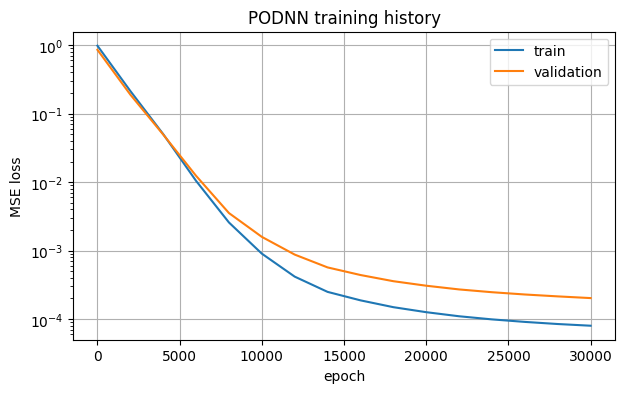

In [26]:
plt.figure(figsize=(7, 4))
plt.semilogy(history["epoch"], history["train_loss"], label="train")
plt.semilogy(history["epoch"], history["validation_loss"], label="validation")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title("PODNN training history")
plt.grid(True)
plt.legend()
plt.show()



## PODNN online prediction

Online evaluation is now only a neural-network forward pass plus reconstruction with the POD basis. No reduced Navier-Stokes solve is performed.


In [27]:
def predict_podnn_coefficients(mu0, mu1):
    mu = np.array([[mu0, mu1]], dtype=np.float32)
    mu_scaled = (mu - mu_mean) / mu_std
    x_test = torch.tensor(np.float32(mu_scaled))

    net.eval()
    with torch.no_grad():
        coeff_scaled = net(x_test).cpu().numpy()[0]

    coeff = coeff_scaled * coeff_scale + coeff_mean
    return coeff


def solve_podnn(mu0, mu1):
    coefficients = predict_podnn_coefficients(mu0, mu1)
    u_podnn = V_podnn @ coefficients

    u_x_podnn = u_podnn[0:speed_n_dofs]
    u_y_podnn = u_podnn[speed_n_dofs:2 * speed_n_dofs]
    p_podnn = u_podnn[2 * speed_n_dofs:]

    info = {
        "mu0": mu0,
        "mu1": mu1,
        "online_stage": "NN forward pass + POD reconstruction",
        "basis_dim": V_podnn.shape[1]
    }

    return u_podnn, u_x_podnn, u_y_podnn, p_podnn, coefficients, info


def compute_relative_errors(u_reference, u_approx):
    du = u_reference[:2 * speed_n_dofs] - u_approx[:2 * speed_n_dofs]
    u_ref = u_reference[:2 * speed_n_dofs]
    velocity_error = np.sqrt(du.T @ X_u @ du) / np.sqrt(u_ref.T @ X_u @ u_ref)

    dp = u_reference[2 * speed_n_dofs:] - u_approx[2 * speed_n_dofs:]
    p_ref = u_reference[2 * speed_n_dofs:]
    pressure_error = np.sqrt(dp.T @ X_p @ dp) / np.sqrt(p_ref.T @ X_p @ p_ref)

    dtotal = u_reference - u_approx
    total_error = np.sqrt(dtotal.T @ X_full @ dtotal) / np.sqrt(u_reference.T @ X_full @ u_reference)

    return total_error, velocity_error, pressure_error


In [28]:
#Testing dataset
# Full-domain structured test grid
mu0_test_grid = np.linspace(0.1, 10.0, 9)
mu1_test_grid = np.linspace(1.0, 3.0, 9)

MU0_TEST, MU1_TEST = np.meshgrid(mu0_test_grid, mu1_test_grid, indexing="ij")

testing_grid = np.column_stack([
    MU0_TEST.ravel(),
    MU1_TEST.ravel()
])

# Extra test points in the difficult high-mu0 region
mu0_high_test = np.linspace(7.0, 10.0, 7)
mu1_high_test = np.linspace(1.0, 3.0, 9)

MU0_HIGH_TEST, MU1_HIGH_TEST = np.meshgrid(
    mu0_high_test,
    mu1_high_test,
    indexing="ij"
)

testing_high_mu0 = np.column_stack([
    MU0_HIGH_TEST.ravel(),
    MU1_HIGH_TEST.ravel()
])

# Random test points over the full domain new seed
np.random.seed(123)

num_random_test = 100

testing_random = np.random.uniform(
    low=P[:, 0],
    high=P[:, 1],
    size=(num_random_test, P.shape[0])
)

testing_set = np.vstack([
    testing_grid,
    testing_high_mu0,
    testing_random
])

testing_set = np.unique(np.round(testing_set, decimals=12), axis=0)

print("testing_set shape:", testing_set.shape)

testing_set shape: (235, 2)


In [ ]:
#results for the testing set
import time
import pandas as pd
results = []

for mu0, mu1 in testing_set:
    start = time.perf_counter()
    u_fom_full, ux_fom, uy_fom, p_fom, fom_info = solve_fom(mu0, mu1)
    fom_time = time.perf_counter() - start

    start = time.perf_counter()
    u_podnn_full, ux_podnn, uy_podnn, p_podnn, coeff_podnn, podnn_info = solve_podnn(mu0, mu1)
    podnn_time = time.perf_counter() - start 

    total_error, velocity_error, pressure_error = compute_relative_errors(
        u_fom_full,
        u_podnn_full
    )

    results.append({ 
        "mu0": mu0,
        "mu1": mu1,
        "velocity_error": velocity_error,
        "pressure_error": pressure_error,
        "total_error": total_error,
        "fom_time": fom_time,
        "podnn_time": podnn_time,
        "speedup": fom_time / podnn_time,
        "fom_iterations": fom_info["iterations"]
    })

df_test_results = pd.DataFrame(results)

print("Average total error:", df_test_results["total_error"].mean())
print("Maximum total error:", df_test_results["total_error"].max())
print("Median total error:", df_test_results["total_error"].median())
print("Average speedup:", df_test_results["speedup"].mean())
print("Average velocity error:", df_test_results["velocity_error"].mean())
print("Average pressure error:", df_test_results["pressure_error"].mean())
df_test_results.loc[df_test_results["total_error"].idxmax()]

Average total error: 0.026760042242434137
Maximum total error: 0.07009385812605858
Median total error: 0.0259226343544916
95th percentile total error: 0.0511276296098941


,143
mu0,7.444435
mu1,1.097158
velocity_error,0.274950
pressure_error,0.061586
total_error,0.070094
fom_time,0.994964
podnn_time,0.001256
speedup,792.362699
fom_iterations,3.000000


In [41]:
print("Average velocity error:", df_test_results["velocity_error"].mean())
print("Max velocity error:", df_test_results["velocity_error"].max())
print("Average pressure error:", df_test_results["pressure_error"].mean())
print("Max pressure error:", df_test_results["pressure_error"].max())
df_test_results.loc[df_test_results["total_error"].idxmin()]

Average velocity error: 0.08914800878896993
Max velocity error: 0.30588800282147954
Average pressure error: 0.020160619458949987
Max pressure error: 0.07533692920262801


,152
mu0,7.500000
mu1,3.000000
velocity_error,0.045947
pressure_error,0.004243
total_error,0.007137
fom_time,1.011864
podnn_time,0.000987
speedup,1025.336217
fom_iterations,3.000000


In [31]:
# Diagnostic: separate POD projection error from NN prediction error on validation snapshots.
# If projection error is small but PODNN error is large, the issue is the NN training.
validation_projection_errors = []
validation_podnn_errors = []

for idx in validation_indices.numpy():
    snapshot = snapshot_matrix[idx]
    projected_coeff = coefficient_matrix[idx]
    projected_solution = V_podnn @ projected_coeff

    mu0, mu1 = training_set[idx]
    podnn_solution, *_ = solve_podnn(mu0, mu1)

    projection_total_error, _, _ = compute_relative_errors(snapshot, projected_solution)
    podnn_total_error, _, _ = compute_relative_errors(snapshot, podnn_solution)

    validation_projection_errors.append(projection_total_error)
    validation_podnn_errors.append(podnn_total_error)

print("Mean validation POD projection error:", np.mean(validation_projection_errors))
print("Mean validation PODNN error on snapshots:", np.mean(validation_podnn_errors))


Mean validation POD projection error: 0.008020824578635248
Mean validation PODNN error on snapshots: 0.02711273795897984


## Error and speedup analysis

This mirrors the final comparison in `Q1.ipynb`, but the online reduced step is the neural network prediction instead of the POD-Galerkin Newton solve.


In [43]:
import pandas as pd

error_decomposition_results = []

for mu0, mu1 in testing_set:
    # FOM solution
    u_fom_full, ux_fom, uy_fom, p_fom, fom_info = solve_fom(mu0, mu1)

    # Best POD projection of the FOM solution
    coeff_projection = project_snapshot_to_pod_coefficients(u_fom_full)
    u_projection_full = V_podnn @ coeff_projection

    # PODNN reconstruction
    u_podnn_full, ux_podnn, uy_podnn, p_podnn, coeff_podnn, podnn_info = solve_podnn(mu0, mu1)

    # Projection errors
    projection_total, projection_velocity, projection_pressure = compute_relative_errors(
        u_fom_full,
        u_projection_full
    )

    # PODNN errors
    podnn_total, podnn_velocity, podnn_pressure = compute_relative_errors(
        u_fom_full,
        u_podnn_full
    )

    # Coefficient prediction error
    coeff_relative_error = (
        np.linalg.norm(coeff_projection - coeff_podnn)
        / np.linalg.norm(coeff_projection)
    )

    error_decomposition_results.append({
        "mu0": mu0,
        "mu1": mu1,

        "projection_total_error": projection_total,
        "projection_velocity_error": projection_velocity,
        "projection_pressure_error": projection_pressure,

        "podnn_total_error": podnn_total,
        "podnn_velocity_error": podnn_velocity,
        "podnn_pressure_error": podnn_pressure,

        "coefficient_relative_error": coeff_relative_error,

        "total_error_gap": podnn_total - projection_total,
        "velocity_error_gap": podnn_velocity - projection_velocity,
        "pressure_error_gap": podnn_pressure - projection_pressure,
    })

df_error_decomposition = pd.DataFrame(error_decomposition_results)

df_error_decomposition

,mu0,mu1,projection_total_error,projection_velocity_error,projection_pressure_error,podnn_total_error,podnn_velocity_error,podnn_pressure_error,coefficient_relative_error,total_error_gap,velocity_error_gap,pressure_error_gap
0,0.1,1.00,0.017722,0.016269,0.045448,0.028402,0.025872,0.075337,0.022198,0.010680,0.009603,0.029889
1,0.1,1.25,0.008598,0.008036,0.018711,0.017612,0.015188,0.051581,0.015371,0.009014,0.007152,0.032870
2,0.1,1.50,0.009698,0.009666,0.011128,0.012785,0.012008,0.033087,0.008332,0.003087,0.002343,0.021959
3,0.1,1.75,0.010063,0.009347,0.030920,0.017387,0.016290,0.050736,0.014180,0.007324,0.006943,0.019816
4,0.1,2.00,0.016513,0.016521,0.015832,0.017640,0.017517,0.025889,0.006206,0.001128,0.000996,0.010056
...,...,...,...,...,...,...,...,...,...,...,...,...
230,10.0,2.00,0.012927,0.022164,0.010141,0.064750,0.125598,0.043542,0.063452,0.051823,0.103434,0.033401
231,10.0,2.25,0.003804,0.017077,0.003107,0.024962,0.161680,0.013399,0.024671,0.021158,0.144603,0.010292
232,10.0,2.50,0.002280,0.018147,0.001488,0.014627,0.126419,0.008293,0.014448,0.012347,0.108272,0.006805
233,10.0,2.75,0.003024,0.018828,0.002610,0.015445,0.112422,0.012441,0.015146,0.012421,0.093594,0.009832


In [44]:
print("Mean projection total error:", df_error_decomposition["projection_total_error"].mean())
print("Mean PODNN total error:", df_error_decomposition["podnn_total_error"].mean())
print("Mean total error gap:", df_error_decomposition["total_error_gap"].mean())

print("Max projection total error:", df_error_decomposition["projection_total_error"].max())
print("Max PODNN total error:", df_error_decomposition["podnn_total_error"].max())
print("Max total error gap:", df_error_decomposition["total_error_gap"].max())

print("Mean coefficient relative error:", df_error_decomposition["coefficient_relative_error"].mean())
print("Max coefficient relative error:", df_error_decomposition["coefficient_relative_error"].max())

Mean projection total error: 0.006925849063575009
Mean PODNN total error: 0.026760042242434137
Mean total error gap: 0.01983419317885913
Max projection total error: 0.02123702780357576
Max PODNN total error: 0.07009385812605858
Max total error gap: 0.06035846398682905
Mean coefficient relative error: 0.02555441803278805
Max coefficient relative error: 0.06941777701944547


mu0, mu1: 7.5 3.0
total error: 0.007136527001862537
velocity error: 0.04594719620569762
pressure error: 0.004243093431004736


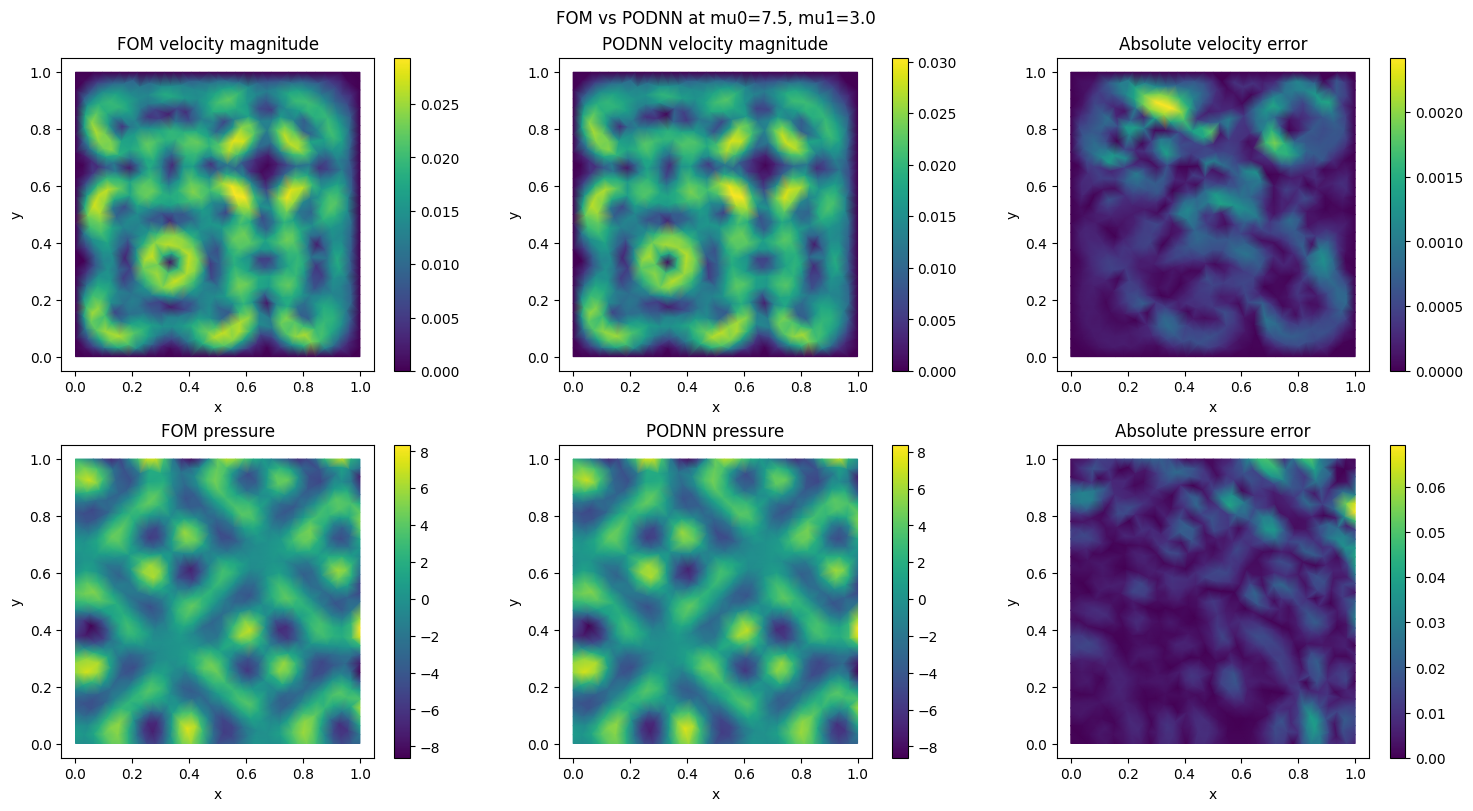

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri


mu0_plot = 7.5
mu1_plot = 3.0
u_fom_full, ux_fom, uy_fom, p_fom, fom_info = solve_fom(mu0_plot, mu1_plot)
u_podnn_full, ux_podnn, uy_podnn, p_podnn, coeff_podnn, podnn_info = solve_podnn(mu0_plot, mu1_plot)

total_error, velocity_error, pressure_error = compute_relative_errors(
    u_fom_full,
    u_podnn_full
)

print("mu0, mu1:", mu0_plot, mu1_plot)
print("total error:", total_error)
print("velocity error:", velocity_error)
print("pressure error:", pressure_error)

def extract_cell0_values(dof_values, dofs_data, reference_element_data, strong_values):
    post = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(
        mesh,
        dofs_data,
        np.asarray(dof_values, dtype=float),
        np.asarray(strong_values, dtype=float)
    )
    return np.asarray(post.numeric_solution)

# Convert FE DOF solutions to mesh-vertex values.
ux_fom_v = extract_cell0_values(ux_fom, speed_dofs_data, speed_reference_element_data, u_x_strong)
uy_fom_v = extract_cell0_values(uy_fom, speed_dofs_data, speed_reference_element_data, u_y_strong)
p_fom_v = extract_cell0_values(p_fom, pressure_dofs_data, pressure_reference_element_data, p_strong)

ux_podnn_v = extract_cell0_values(ux_podnn, speed_dofs_data, speed_reference_element_data, u_x_strong)
uy_podnn_v = extract_cell0_values(uy_podnn, speed_dofs_data, speed_reference_element_data, u_y_strong)
p_podnn_v = extract_cell0_values(p_podnn, pressure_dofs_data, pressure_reference_element_data, p_strong)

# Velocity magnitude and errors.
vel_fom_v = np.sqrt(ux_fom_v**2 + uy_fom_v**2)
vel_podnn_v = np.sqrt(ux_podnn_v**2 + uy_podnn_v**2)
vel_error_v = np.abs(vel_fom_v - vel_podnn_v)

p_error_v = np.abs(p_fom_v - p_podnn_v)

coordinates = mesh.cell0_ds_coordinates()
x = coordinates[0, :]
y = coordinates[1, :]
triang = mtri.Triangulation(x, y)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

plot_data = [
    (vel_fom_v, "FOM velocity magnitude"),
    (vel_podnn_v, "PODNN velocity magnitude"),
    (vel_error_v, "Absolute velocity error"),
    (p_fom_v, "FOM pressure"),
    (p_podnn_v, "PODNN pressure"),
    (p_error_v, "Absolute pressure error"),
]

for ax, (field, title) in zip(axes.ravel(), plot_data):
    tpc = ax.tripcolor(triang, field, shading="gouraud")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(tpc, ax=ax)

fig.suptitle(f"FOM vs PODNN at mu0={mu0_plot}, mu1={mu1_plot}")
plt.show()

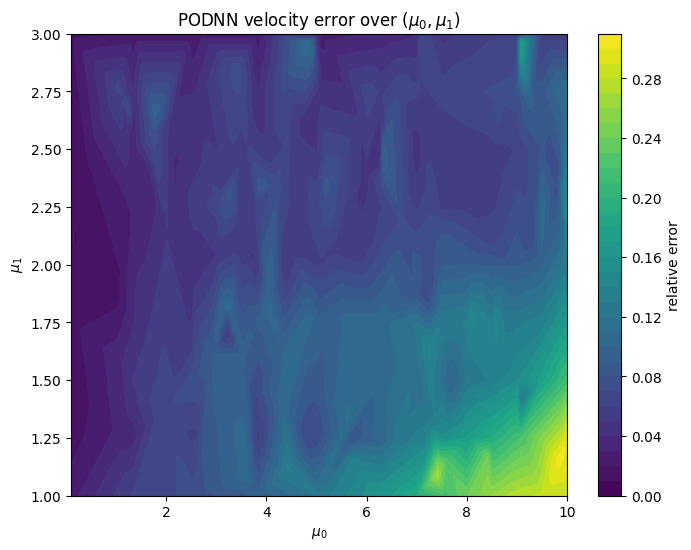

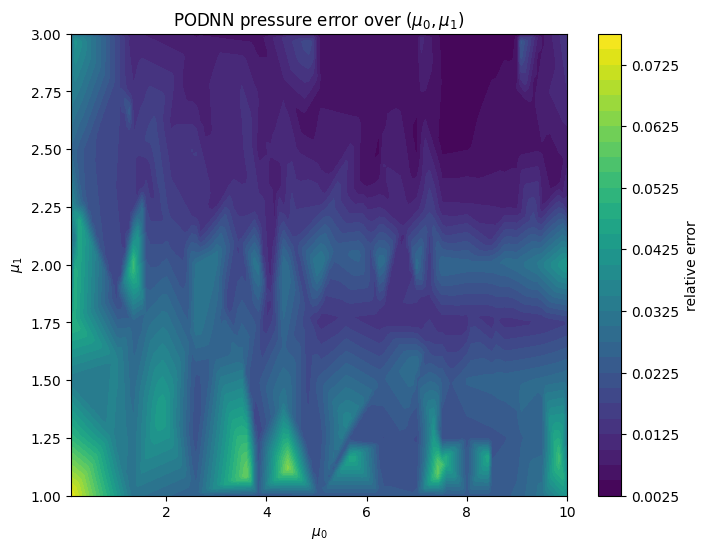

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def plot_podnn_error_heatmap(df, error_column, title):
    mu0 = df["mu0"].to_numpy()
    mu1 = df["mu1"].to_numpy()
    error = df[error_column].to_numpy()

    mu0_grid = np.linspace(mu0.min(), mu0.max(), 120)
    mu1_grid = np.linspace(mu1.min(), mu1.max(), 120)

    MU0, MU1 = np.meshgrid(mu0_grid, mu1_grid, indexing="ij")

    ERROR = griddata(
        points=(mu0, mu1),
        values=error,
        xi=(MU0, MU1),
        method="linear"
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    heatmap = ax.contourf(
        MU0,
        MU1,
        ERROR,
        levels=30,
        cmap="viridis"
    )

    ax.set_xlabel(r"$\mu_0$")
    ax.set_ylabel(r"$\mu_1$")
    ax.set_title(title)

    cbar = fig.colorbar(heatmap, ax=ax)
    cbar.set_label("relative error")

    plt.show()


plot_podnn_error_heatmap(
    df_test_results,
    "velocity_error",
    r"PODNN velocity error over $(\mu_0, \mu_1)$"
)

plot_podnn_error_heatmap(
    df_test_results,
    "pressure_error",
    r"PODNN pressure error over $(\mu_0, \mu_1)$"
)

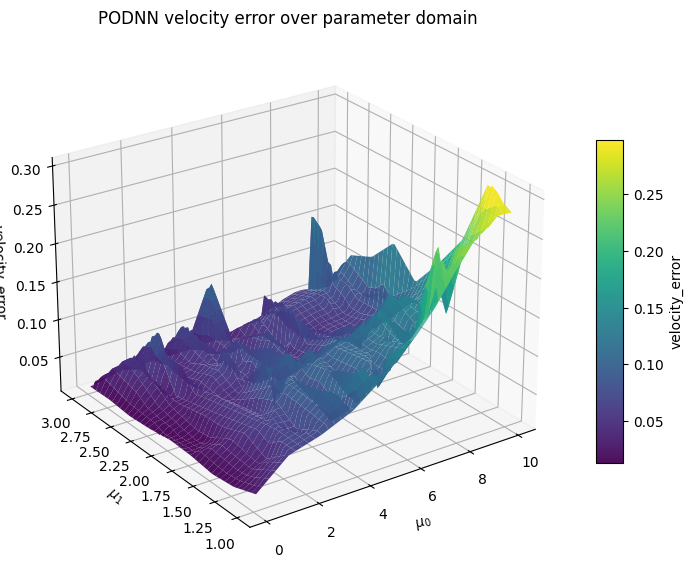

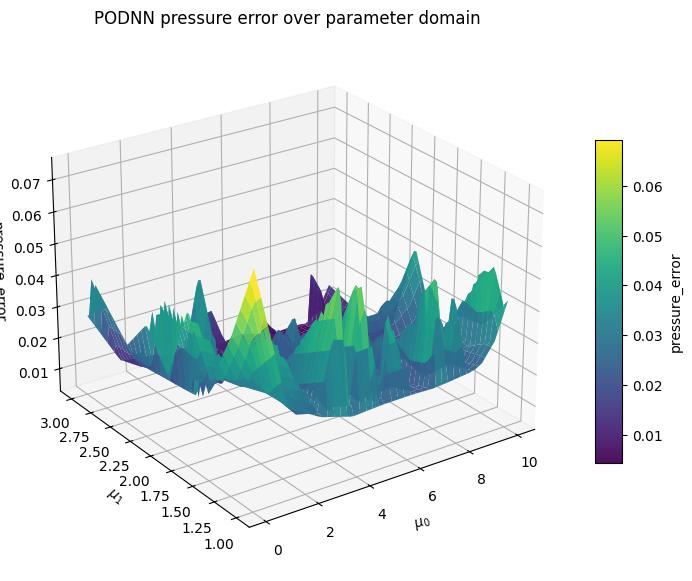

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def plot_error_surface_3d(df, error_column, title):
    mu0 = df["mu0"].to_numpy()
    mu1 = df["mu1"].to_numpy()
    error = df[error_column].to_numpy()

    mu0_grid = np.linspace(mu0.min(), mu0.max(), 80)
    mu1_grid = np.linspace(mu1.min(), mu1.max(), 80)

    MU0, MU1 = np.meshgrid(mu0_grid, mu1_grid, indexing="ij")

    ERROR = griddata(
        points=(mu0, mu1),
        values=error,
        xi=(MU0, MU1),
        method="linear"
    )

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    surface = ax.plot_surface(
        MU0,
        MU1,
        ERROR,
        cmap="viridis",
        edgecolor="none",
        alpha=0.95
    )


    ax.set_xlabel(r"$\mu_0$")
    ax.set_ylabel(r"$\mu_1$")
    ax.set_zlabel(error_column)
    ax.set_title(title)
    ax.view_init(elev=25, azim=-125)

    fig.colorbar(surface, ax=ax, shrink=0.6, aspect=12, label=error_column)

    plt.show()


plot_error_surface_3d(
    df_test_results,
    "velocity_error",
    "PODNN velocity error over parameter domain"
)

plot_error_surface_3d(
    df_test_results,
    "pressure_error",
    "PODNN pressure error over parameter domain"
)